In [3]:
# !pip install numpy scikit-learn gurobipy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings("ignore")
from MIP import best_subset_full, discrete_first_order, best_subset_mio

Matplotlib is building the font cache; this may take a moment.


# Data generation

In [3]:
def generate_data(n, p, k0, rho=0.5, SNR=3.0, seed=0):
    
    rng = np.random.default_rng(seed)

    idx = np.arange(p)
    Sigma = rho ** np.abs(idx[:, None] - idx[None, :])
    L = np.linalg.cholesky(Sigma)
    X = rng.standard_normal((n, p)) @ L.T

    X = X - X.mean(axis=0)
    X = X / np.linalg.norm(X, axis=0)

    beta0 = np.zeros(p)
    indices = np.round(np.linspace(0, p - 1, k0)).astype(int)
    beta0[indices] = 1.0

    signal_var = np.var(X @ beta0)
    sigma2 = signal_var / SNR
    eps = rng.normal(0, np.sqrt(sigma2), n)
    y = X @ beta0 + eps
    return X, y, beta0

In [4]:
def prediction_error(X, beta_hat, beta0):

    num = np.sum((X @ beta_hat - X @ beta0) ** 2)
    den = np.sum((X @ beta0) ** 2)
    if den < 1e-10:
        return 0.0
    return num / den

def select_k_by_validation(X_train, y_train, X_val, y_val,
                            k_range, method="mio", time_limit=60):

    best_k = k_range[0]
    best_val_loss = np.inf
    for k in k_range:
        if method == "mio":
            result = best_subset_full(X_train, y_train, k,
                                      time_limit=time_limit, n_restarts=20)
            beta = result["beta_mio"]
            if beta is None:
                beta = result["beta_fo"]
        else:  # first_order
            beta, _ = discrete_first_order(X_train, y_train, k, n_restarts=20)
            
        val_loss = np.mean((y_val - X_val @ beta) ** 2)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_k = k
    return best_k

# Lasso, MIP, First Order only

In [19]:
np.random.seed(10)
n, p, k0 = 1000, 100, 10
rho_values = [0.5, 0.8, 0.9]
SNR = 3.0
n_repeats = 3 
k_range = list(range(max(1, k0 - 5), k0 + 6))
results = {rho: {"mio_w": [], "mio_c": [], "lasso": [], "fo": []} for rho in rho_values}

for rho in rho_values:
    print(f"\n=== rho = {rho} ===")
    for rep in range(n_repeats):
        X, y, beta0 = generate_data(n, p, k0, rho=rho, SNR=SNR, seed=rep)

        n_train = int(0.6 * n)
        n_val   = int(0.2 * n)
        X_train, y_train = X[:n_train], y[:n_train]
        X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
        X_test,  y_test  = X[n_train+n_val:], y[n_train+n_val:]

        # mio warm start
        t0 = time.time()
        best_k_mio = select_k_by_validation(
            X_train, y_train, X_val, y_val,
            k_range, method="mio", time_limit=30
        )
        result = best_subset_full(X_train, y_train, best_k_mio,
                                  time_limit=60, n_restarts=30)
        beta_mio = result["beta_mio"] if result["beta_mio"] is not None else result["beta_fo"]
        pe_mio = prediction_error(X_test, beta_mio, beta0)
        nnz_mio = int(np.sum(np.abs(beta_mio) > 1e-6))
        gap_mio = result["mio_gap"]
        t_mio = time.time() - t0

        # mio cold start
        t0 = time.time()
        best_k_mio_c = select_k_by_validation(
            X_train, y_train, X_val, y_val,
            k_range, method="mio", time_limit=30
        )
        beta_mio_c, _, gap_mio_c, _ = best_subset_mio(X_train, y_train, best_k_mio_c, time_limit=60)
        pe_mio_c = prediction_error(X_test, beta_mio_c, beta0)
        nnz_mio_c = int(np.sum(np.abs(beta_mio_c) > 1e-6))
        t_mio_c = time.time() - t0
        
        # first order
        t0 = time.time()
        best_k_fo = select_k_by_validation(
            X_train, y_train, X_val, y_val,
            k_range, method="first_order", time_limit=30
        )
        beta_fo, _ = discrete_first_order(X_train, y_train, best_k_fo, n_restarts=50)
        pe_fo = prediction_error(X_test, beta_fo, beta0)
        nnz_fo = int(np.sum(np.abs(beta_fo) > 1e-6))
        t_fo = time.time() - t0
        
        # lasso
        t0 = time.time()
        lasso_cv = LassoCV(cv=5, max_iter=5000).fit(X_train, y_train)
        beta_lasso = lasso_cv.coef_
        pe_lasso = prediction_error(X_test, beta_lasso, beta0)
        nnz_lasso = int(np.sum(np.abs(beta_lasso) > 1e-6))
        t_lasso = time.time() - t0
        results[rho]["mio_w"].append({
            "pred_err": pe_mio, "nnz": nnz_mio,
            "gap": gap_mio, "time": t_mio, "k": best_k_mio
        })
        results[rho]["mio_c"].append({
            "pred_err": pe_mio_c, "nnz": nnz_mio_c,
            "gap": gap_mio_c, "time": t_mio_c, "k": best_k_mio_c
        })
        results[rho]["lasso"].append({
            "pred_err": pe_lasso, "nnz": nnz_lasso, "time": t_lasso
        })
        results[rho]["fo"].append({
            "pred_err": pe_fo, "nnz": nnz_fo, "time": t_fo, "k": best_k_fo
        })
        print(f"  rep={rep+1} | MIO: PE={pe_mio:.4f}, nnz={nnz_mio}, gap={gap_mio:.3f} "
              f"| FO: PE={pe_fo:.4f}, nnz={nnz_fo} "
              f"| Lasso: PE={pe_lasso:.4f}, nnz={nnz_lasso}")



=== rho = 0.5 ===
  rep=1 | MIO: PE=0.0245, nnz=12, gap=0.000 | FO: PE=0.0245, nnz=12 | Lasso: PE=0.0259, nnz=30
  rep=2 | MIO: PE=0.0104, nnz=12, gap=0.000 | FO: PE=0.0013, nnz=10 | Lasso: PE=0.0155, nnz=37
  rep=3 | MIO: PE=0.0041, nnz=10, gap=0.000 | FO: PE=0.0041, nnz=10 | Lasso: PE=0.0220, nnz=23

=== rho = 0.8 ===
  rep=1 | MIO: PE=0.0292, nnz=12, gap=0.000 | FO: PE=0.0289, nnz=13 | Lasso: PE=0.0275, nnz=26
  rep=2 | MIO: PE=0.0016, nnz=10, gap=0.000 | FO: PE=0.0097, nnz=12 | Lasso: PE=0.0175, nnz=38
  rep=3 | MIO: PE=0.0046, nnz=10, gap=0.000 | FO: PE=0.0074, nnz=11 | Lasso: PE=0.0224, nnz=28

=== rho = 0.9 ===
  rep=1 | MIO: PE=0.0353, nnz=12, gap=0.000 | FO: PE=0.0365, nnz=12 | Lasso: PE=0.0263, nnz=29
  rep=2 | MIO: PE=0.0019, nnz=10, gap=0.000 | FO: PE=0.0039, nnz=12 | Lasso: PE=0.0186, nnz=39
  rep=3 | MIO: PE=0.0142, nnz=10, gap=0.042 | FO: PE=0.0097, nnz=12 | Lasso: PE=0.0224, nnz=33


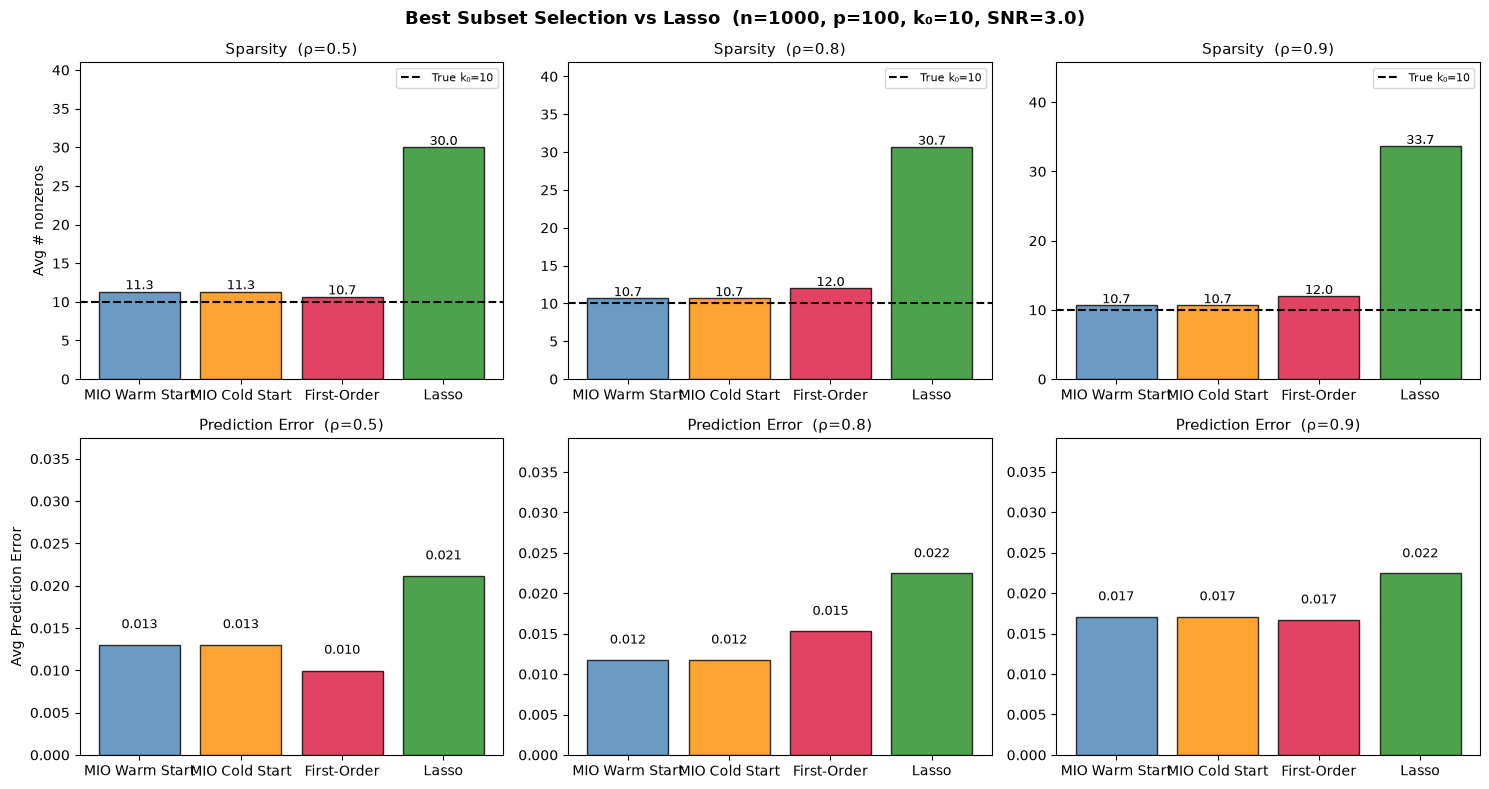

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f"Best Subset Selection vs Lasso  (n={n}, p={p}, k₀={k0}, SNR={SNR})",
             fontsize=13, fontweight="bold")
for col, rho in enumerate(rho_values):
    r = results[rho]
    mio_pe    = [d["pred_err"] for d in r["mio_w"]]
    mio_pe_c    = [d["pred_err"] for d in r["mio_c"]]
    lasso_pe  = [d["pred_err"] for d in r["lasso"]]
    fo_pe     = [d["pred_err"] for d in r["fo"]]
    mio_nnz   = [d["nnz"] for d in r["mio_w"]]
    mio_nnz_c   = [d["nnz"] for d in r["mio_c"]]
    lasso_nnz = [d["nnz"] for d in r["lasso"]]
    fo_nnz    = [d["nnz"] for d in r["fo"]]
    methods = ["MIO Warm Start", "MIO Cold Start", "First-Order", "Lasso"]
    pe_vals  = [np.mean(mio_pe), np.mean(mio_pe_c), np.mean(fo_pe), np.mean(lasso_pe)]
    nnz_vals = [np.mean(mio_nnz), np.mean(mio_nnz_c), np.mean(fo_nnz), np.mean(lasso_nnz)]
    colors   =  ["steelblue", "darkorange", "crimson", "forestgreen"]
    # Górny wiersz: sparsity (liczba niezerowych)
    ax_top = axes[0, col]
    bars = ax_top.bar(methods, nnz_vals, color=colors, alpha=0.8, edgecolor="black")
    ax_top.axhline(k0, color="black", linestyle="--", linewidth=1.5,
                   label=f"True k₀={k0}")
    ax_top.set_title(f"ρ = {rho}", fontsize=11)
    ax_top.set_ylabel("Avg # nonzeros" if col == 0 else "")
    ax_top.legend(fontsize=8)
    ax_top.set_ylim(0, max(nnz_vals) * 1.3 + 2)
    for bar, val in zip(bars, nnz_vals):
        ax_top.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                    f"{val:.1f}", ha="center", fontsize=9)
    # Dolny wiersz: prediction error
    ax_bot = axes[1, col]
    bars = ax_bot.bar(methods, pe_vals, color=colors, alpha=0.8, edgecolor="black")
    ax_bot.set_ylabel("Avg Prediction Error" if col == 0 else "")
    ax_bot.set_ylim(0, max(pe_vals) * 1.3 + 0.01)
    for bar, val in zip(bars, pe_vals):
        ax_bot.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                    f"{val:.3f}", ha="center", fontsize=9)
axes[0, 0].set_title(f"Sparsity  (ρ={rho_values[0]})", fontsize=11)
for col, rho in enumerate(rho_values):
    axes[0, col].set_title(f"Sparsity  (ρ={rho})", fontsize=11)
    axes[1, col].set_title(f"Prediction Error  (ρ={rho})", fontsize=11)
plt.tight_layout()
plt.savefig("plots/figure4_replication.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
print("\n=== Ewolucja MIO gap ===")
X_demo, y_demo, beta0_demo = generate_data(500, 100, 10, rho=0.5, SNR=3.0, seed=99)
X_demo = X_demo - X_demo.mean(0)
X_demo = X_demo / np.linalg.norm(X_demo, axis=0)
k_vals_demo = [5, 10, 15]
gap_history = {}
for k_demo in k_vals_demo:
    # Warm start z Alg. 2
    beta_fo_demo, _ = discrete_first_order(X_demo, y_demo, k_demo, n_restarts=30)
    # MIO z verbose=True żeby zobaczyć postęp
    model_data = []
    class GapCallback:
        """Callback zbierający ewolucję gap."""
        def __init__(self):
            self.times = []
            self.gaps = []
            self.obj_vals = []
    # Uruchom MIO i zbierz gap po zakończeniu
    beta_m, z_m, gap_m, obj_m = best_subset_mio(
        X_demo, y_demo, k_demo,
        time_limit=120,
        beta_init=beta_fo_demo
    )
    gap_history[k_demo] = gap_m
    print(f"  k={k_demo}: final gap = {gap_m:.4f}, obj = {obj_m:.4f}, nnz = {int(np.sum(np.abs(beta_m)>1e-6))}")
print("\nMIO gap (certyfikat suboptymalnościi):")
for k_demo, gap in gap_history.items():
    print(f"  k={k_demo}: gap = {gap:.2%}  {'✓ optimal' if gap < 0.01 else '(not certified)'}")
# ============================================================
# Komórka 7: Tabela wynikowa (jak Table 1 z paperu)
# ============================================================

print("\n" + "="*70)
print(f"{'Method':<18} {'rho':<8} {'Avg Pred.Err':<16} {'Avg NNZ':<12} {'Avg Time(s)'}")
print("="*70)
for rho in rho_values:
    r = results[rho]
    for method, key in [("MIO Warm Start", "mio_w"), ("MIO Cold Start", "mio_c"), ("First-Order", "fo"), ("Lasso", "lasso")]:
        avg_pe   = np.mean([d["pred_err"] for d in r[key]])
        avg_nnz  = np.mean([d["nnz"] for d in r[key]])
        avg_time = np.mean([d["time"] for d in r[key]])
        print(f"{method:<18} {rho:<8} {avg_pe:<16.4f} {avg_nnz:<12.1f} {avg_time:.1f}")
    print("-"*70)


=== Ewolucja MIO gap ===
  k=5: final gap = 0.0000, obj = 3.5299, nnz = 5
  k=10: final gap = 0.0000, obj = 1.5487, nnz = 10
  k=15: final gap = 0.0000, obj = 1.4610, nnz = 15

MIO gap (certyfikat suboptymalnościi):
  k=5: gap = 0.00%  ✓ optimal
  k=10: gap = 0.00%  ✓ optimal
  k=15: gap = 0.00%  ✓ optimal

Method             rho      Avg Pred.Err     Avg NNZ      Avg Time(s)
MIO Warm Start     0.5      0.0130           11.3         41.9
MIO Cold Start     0.5      0.0130           11.3         52.7
First-Order        0.5      0.0100           10.7         0.8
Lasso              0.5      0.0211           30.0         0.0
----------------------------------------------------------------------
MIO Warm Start     0.8      0.0118           10.7         151.3
MIO Cold Start     0.8      0.0118           10.7         163.6
First-Order        0.8      0.0153           12.0         3.8
Lasso              0.8      0.0225           30.7         0.0
-----------------------------------------------